In [1]:
!pip install langgraph

# LangGraph 예제 : 상태: counter + log + done,
# 루프 + 종료 조건 + 체크포인트(MemorySaver) + 중간중단/재개 예제

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver  # 메모리 기반 체크포인터

# 1) 상태(State) 정의
class State(TypedDict):
    counter: int      # 몇 번째 작업인지 저장할 정수 값
    log: List[str]      # 진행 상황을 문자열 리스트로 누적 기록
    done: bool       # 루프를 더 돌릴지 말지 결정하는 플래그 (True면 종료)

In [3]:
# 2) 노드 함수 정의
def init_state(state: State) -> State:
    # 처음 한번만 실행되는 초기화 노드. state에 기본값이 없으면 초기값을 넣어주고 로그에 시작메시지를 남김
    # 최초 호출 시에만 기본값 설정 (혹시 키가 없을 수도 있으므로 방어 코드)
    if "counter" not in state:        # state 딕셔너리에 'counter' 키가 없으면
        state["counter"] = 0         # counter를 0으로 초기화
    if "log" not in state:             # 'log' 키가 없으면
        state["log"] = []             # 빈 리스트로 초기화 (로그 목록)
    if "done" not in state:            # 'done' 키가 없으면
        state["done"] = False         # 아직 종료하지 않았으므로 False로 설정

    state["log"].append("그래프 실행 시작 (init_state 실행됨)")  # 초기화가 실행되었다는 로그 추가
    return state                      # 수정된 state를 반환 (다음 노드로 전달)


def worker(state: State) -> State:
    """
    실제로 반복해서 호출될 작업 노드. counter를 1 증가시키고 log에 현재 step을 남김.
    - 일정 조건을 만족하면 done=True 로 바꿔서 루프 종료 신호를 보냄
    """
    state["counter"] += 1
    step = state["counter"]   # 가독성을 위해 step 변수에 담아 사용

    state["log"].append(f"{step}번째 작업 수행 (worker 노드)")  # 몇 번째 작업인지 로그에 기록

    # 종료 조건: counter가 3 이상이 되면 루프를 멈추도록 플래그 설정
    if step >= 3:                     # 만약 step(=counter)이 3 이상이면
        state["done"] = True          # done 플래그를 True로 바꿔서 "이제 끝낼 준비 됨" 표시
        state["log"].append(          # 종료 조건에 도달했다는 설명 로그 남김
            f"counter가 {step}이므로 종료 조건 도달 → 다음 단계에서 루프를 종료"
        )
    return state


def route_after_worker(state: State) -> str:
    """
    worker 실행 이후 다음으로 어디로 갈지 결정하는 라우터 함수.
    - done이 False면 계속 worker로 (루프), done이 True면 END로 (그래프 종료)
    """
    # done이 False면 "continue" 문자열, True면 "stop" 문자열 반환
    # 이 문자열은 아래에서 add_conditional_edges의 key로 사용됨
    return "continue" if not state["done"] else "stop"

In [5]:
# 3) 그래프 구성 함수
def build_app():
    """
    StateGraph를 만들고, init_state → worker → (계속/종료) 플로우를 구성한 뒤
    - MemorySaver 체크포인터를 붙여서 컴파일한 runnable(app)을 반환.
    """
    graph = StateGraph(State)

    # 노드 등록
    graph.add_node("init", init_state)
    graph.add_node("worker", worker)
    # START가 엔트리 포인트 역할을 하고 있기 때문에 별도로 graph.entry_point()를 설정할 필요가 없다.
    # 엣지(흐름) 연결
    graph.add_edge(START, "init")
    graph.add_edge("init", "worker")

    # worker 이후에는 조건에 따라 다시 worker or END 로 분기 (루프 + 종료)
    graph.add_conditional_edges(
        "worker",                   # 기준 노드: worker 실행이 끝난 후
        route_after_worker,         # state를 받아 "continue"/"stop"을 반환하는 라우터 함수
        {
            "continue": "worker",   # route_after_worker가 "continue"를 반환하면 다시 worker로 (루프)
            "stop": END,            # "stop"을 반환하면 END(그래프 종료)로 이동
        },
    )

    # 체크포인터 등록 (여기서는 메모리 기반)
    checkpointer = MemorySaver()    # MemorySaver 인스턴스를 생성 (메모리에 체크포인트 저장)

    # compile 시 checkpointer를 넘겨주면
    # 같은 thread_id로 실행할 때 상태를 저장/복원할 수 있음
    app = graph.compile(checkpointer=checkpointer)  # 그래프를 실행 가능한 app으로 컴파일
    return app

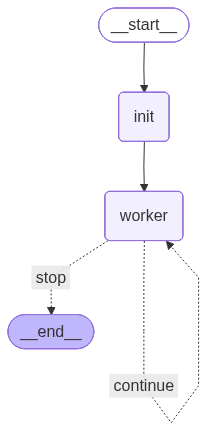


[1차 실행] counter = 1, done = False 상태에서 중단

[1차 실행] counter = 0, done = False
  로그(최근 상태 기준):

[1차 실행] counter = 0, done = False
  로그(최근 상태 기준):
   - 그래프 실행 시작 (init_state 실행됨)

[1차 실행] counter = 1, done = False
  로그(최근 상태 기준):
   - 그래프 실행 시작 (init_state 실행됨)
   - 1번째 작업 수행 (worker 노드)

 counter=1, done=False 상태에서 일부러 중단~~~

[현재 저장된 체크포인트 상태] get_state() ===
 snapshot.values['counter'] = 1
 snapshot.values['done'] = False
 snapshot.values['log']:
   - 그래프 실행 시작 (init_state 실행됨)
   - 1번째 작업 수행 (worker 노드)

[2차 실행] 같은 thread_id + 입력 None 으로 이어서 실행 (stream) ===

[2차 실행] counter = 1, done = False
  로그(최근 상태 기준):
   - 그래프 실행 시작 (init_state 실행됨)
   - 1번째 작업 수행 (worker 노드)

[2차 실행] counter = 2, done = False
  로그(최근 상태 기준):
   - 그래프 실행 시작 (init_state 실행됨)
   - 1번째 작업 수행 (worker 노드)
   - 2번째 작업 수행 (worker 노드)

[2차 실행] counter = 3, done = True
  로그(최근 상태 기준):
   - 그래프 실행 시작 (init_state 실행됨)
   - 1번째 작업 수행 (worker 노드)
   - 2번째 작업 수행 (worker 노드)
   - 3번째 작업 수행 (worker 노드)
   - counter가 3이므로 종료 조건 

In [6]:
if __name__ == "__main__":
    app = build_app()
    # 그래프 구조 시각화
    try:
        from IPython.display import Image, display
        g = app.get_graph()                 # 내부 그래프 구조를 가져옴 (시각화용)
        png_bytes = g.draw_mermaid_png()  # mermaid 다이어그램을 PNG 바이트로 렌더링
        display(Image(data=png_bytes))       # 주피터 노트북에 그래프 PNG 표시
    except Exception:
        # 노트북/환경에 따라 시각화가 안될 수도 있으니, 에러는 무시
        pass

    # thread_id는 "이 대화/세션"을 구분하는 키라고 보면 됨.
    # 같은 thread_id로 여러 번 실행하면 체크포인트에 상태가 누적/갱신됨.
    config = {
        "configurable": {                  # LangGraph가 내부적으로 사용하는 설정 공간
            "thread_id": "demo-thread-1"  # 이 실행 흐름을 구분하는 ID (같으면 같은 세션으로 취급)
        }
    }

    # 초기 상태 (counter=0, log는 비어 있고, done=False)
    init_state_value: State = {            # 처음 실행할 때 전달할 초기 state 값
        "counter": 0,                    # 아직 한 번도 worker가 실행되지 않았으므로 0
        "log": [],                        # 로그는 빈 리스트로 시작
        "done": False,                   # 아직 종료 조건에 도달하지 않았으므로 False
    }

    # 1차 실행: stream() 으로 실행하다가 ➜ counter == 1, done == False 상태에서 "의도적으로 중단"
    print("\n[1차 실행] counter = 1, done = False 상태에서 중단")

    # app.stream(...) : 그래프 실행을 "스트리밍" 방식으로 한 단계씩 내보냄
    #   - stream_mode="values" 이므로 각 단계마다 State(dict)가 그대로 yield됨
    for chunk in app.stream(init_state_value, config=config, stream_mode="values"):
        state = chunk      # chunk 가 곧 State dict이므로 이름만 state로 바꿔 사용

        print(f"\n[1차 실행] counter = {state['counter']}, done = {state['done']}")
        print("  로그(최근 상태 기준):")
        for line in state["log"]:    # 로그 리스트를 순회하면서 각 메시지 출력
            print("   -", line)

        # 여기서 끊고 싶다: counter == 1, done == False 상태
        if state["counter"] == 1 and not state["done"]:
            # counter가 1이고 아직 done이 False인 시점에서 의도적으로 반복을 중단
            print("\n counter=1, done=False 상태에서 일부러 중단~~~")
            break     # for 루프를 빠져나감 → 그래프 전체는 END까지 가지 않음

    # 이 시점까지의 상태는 체크포인터(MemorySaver)에 저장되어 있음.
    snapshot = app.get_state(config)     # 현재 thread_id의 최신 체크포인트 상태를 가져옴
    print("\n[현재 저장된 체크포인트 상태] get_state() ===")
    print(f" snapshot.values['counter'] = {snapshot.values['counter']}")  # 체크포인트의 counter 출력
    print(f" snapshot.values['done'] = {snapshot.values['done']}")       # 체크포인트의 done 값 출력
    print(" snapshot.values['log']:")
    for line in snapshot.values["log"]:    # 체크포인트에 저장된 로그 전체 출력
        print("   -", line)

    # 2차 실행: 같은 thread_id + input=None 으로 "이어서 실행"
    #   ➜ counter=1 상태부터 다시 시작해서, 조건 만족할 때까지 계속
    print("\n[2차 실행] 같은 thread_id + 입력 None 으로 이어서 실행 (stream) ===")

    # 여기서는 input을 None으로 주는 것이 포인트:
    # - 처음부터 다시 시작하는 것이 아니라 기존 thread_id에 저장된 체크포인트 상태에서 이어서 실행
    for chunk in app.stream(None, config=config, stream_mode="values"):
        state = chunk                    # 마찬가지로 State dict
        print(f"\n[2차 실행] counter = {state['counter']}, done = {state['done']}")
        print("  로그(최근 상태 기준):")
        for line in state["log"]:
            print("   -", line)

    # 2차 실행이 끝나면 (END 도달) 다시 한 번 최종 상태를 확인
    final_snapshot = app.get_state(config)               # 최종 체크포인트 상태 다시 조회
    print("\n[최종 체크포인트 상태] get_state() ===")
    print(f" counter: {final_snapshot.values['counter']}")  # 최종 counter 값 (3 이상이어야 함)
    print(f" done   : {final_snapshot.values['done']}")     # 최종 done 값 (True 여야 함)
    print(" 로그:")
    for line in final_snapshot.values["log"]:   # 최종 로그 전체 출력
        print("   -", line)

    # (옵션) invoke(None, ...) 패턴도 동일하게 사용 가능
    print("\n[옵션] invoke(None, ...) 으로도 이어서 실행 가능 패턴 예시 ===")
    # 이미 위에서 END까지 도달했기 때문에 여기서는 특별한 추가 작업은 없을 수 있음.
    final_state: State = app.invoke(None, config=config)  # 현재 체크포인트 이후 남은 작업 실행
    print("invoke(None, ...) 호출 결과 State ===")
    print(f"  counter: {final_state['counter']}")   # 최종 counter 다시 출력
    print(f"  done   : {final_state['done']}")      # 최종 done 다시 출력